#Project: Bitcoin Price Prediction using Machine Learning




#1. Importing Necessary Libraries and Dataset:

In [2]:
# Import required Python libraries

import pandas as pd      # Pandas (used for handling and analyzing datasets)

import numpy as np       # NumPy (used for numerical and mathematical operations)

import matplotlib.pyplot as plt   # Matplotlib (used for plotting graphs)
import seaborn as sns             # Seaborn (used for advanced data visualization)

from sklearn.model_selection import train_test_split  # Sklearn (used for splitting data for training and testing)
from sklearn.preprocessing import StandardScaler      # Sklearn (used for data preprocessing)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Sklearn (used for model evaluation)

import xgboost as xgb    # XGBoost (used for high-performance machine learning prediction)

Uploading the File

In [10]:
from google.colab import files
uploaded=files.upload()

Saving bitcoin.csv to bitcoin.csv


Reading Dataset

In [13]:
bitcoin_data = pd.read_csv("bitcoin.csv")

In [15]:
bitcoin_data.columns (Checking columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

#2. Data Preprocessing:

Handle missing values by filling with previous values

In [17]:
bitcoin_data.fillna(method='ffill', inplace=True)
# (Fills missing values using previous data points)

Convert Date column to DateTime format

In [20]:
bitcoin_data['Date'] = pd.to_datetime(bitcoin_data['Date'])
# (Converts Date column into datetime format)

Set Date as index

In [21]:
bitcoin_data.set_index('Date', inplace=True)
# (Makes Date column the index for time-series analysis)

• Normalize numerical features using MinMaxScaler for uniform scaling.

In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# (Creates a MinMaxScaler object to scale values)

data_scaled = scaler.fit_transform(bitcoin_data)
# (Scales all numerical values in the dataset between 0 and 1)

Create new features like Moving Averages (SMA, EMA), Bollinger Bands, and
RSI.

In [29]:
# Remove rows with missing values created by indicators
bitcoin_data = bitcoin_data.dropna()

In [30]:
# --- Technical Indicators ---
bitcoin_data['SMA_10'] = bitcoin_data['Close'].rolling(window=10).mean()
bitcoin_data['EMA_10'] = bitcoin_data['Close'].ewm(span=10, adjust=False).mean()

bitcoin_data['MA_20'] = bitcoin_data['Close'].rolling(window=20).mean()
bitcoin_data['STD_20'] = bitcoin_data['Close'].rolling(window=20).std()

bitcoin_data['Upper_Band'] = bitcoin_data['MA_20'] + (bitcoin_data['STD_20'] * 2)
bitcoin_data['Lower_Band'] = bitcoin_data['MA_20'] - (bitcoin_data['STD_20'] * 2)

delta = bitcoin_data['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
bitcoin_data['RSI'] = 100 - (100 / (1 + rs))

# Remove missing values
bitcoin_data = bitcoin_data.dropna()

Split dataset into training (80%) and testing (20%) sets.

In [31]:
from sklearn.model_selection import train_test_split

# Select features (input variables)
X = bitcoin_data[['SMA_10', 'EMA_10', 'Upper_Band', 'Lower_Band', 'RSI']]

# Select target variable (what we want to predict)
y = bitcoin_data['Close']

# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# (80% data used for training and 20% for testing the model)

#3. Exploratory Data Analysis (EDA):

Visualize Bitcoin price trends over time using line charts.

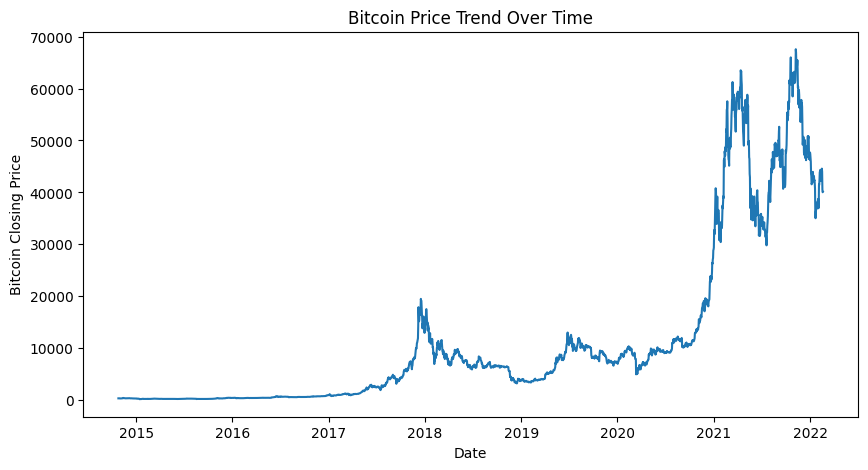

In [32]:
import matplotlib.pyplot as plt

# Plot Bitcoin closing price over time
plt.figure(figsize=(10,5))
plt.plot(bitcoin_data.index, bitcoin_data['Close'])

plt.title("Bitcoin Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Bitcoin Closing Price")
plt.show()

Explanation:- This code plots a line chart of Bitcoin closing prices over time to visualize the price trend.

Analyze the impact of volume, volatility, and historical patterns on price
changes.

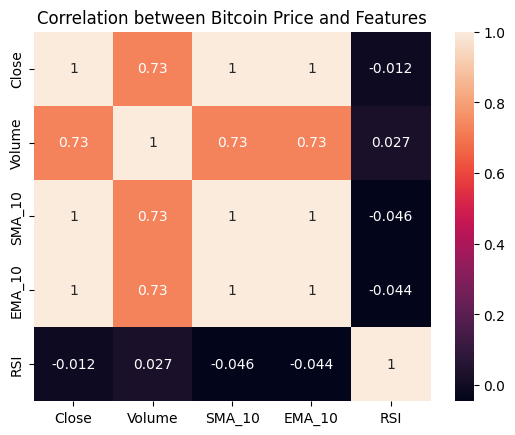

In [26]:
# Correlation analysis
import seaborn as sns
import matplotlib.pyplot as plt

correlation = bitcoin_data[['Close', 'Volume', 'SMA_10', 'EMA_10', 'RSI']].corr()

sns.heatmap(correlation, annot=True)
plt.title("Correlation between Bitcoin Price and Features")
plt.show()

Explanation:- This code analyzes the relationship between Bitcoin price,trading volume, and historical indicators using a correlation heatmap to understand their impact on price changes.

Identify correlations between different technical indicators.

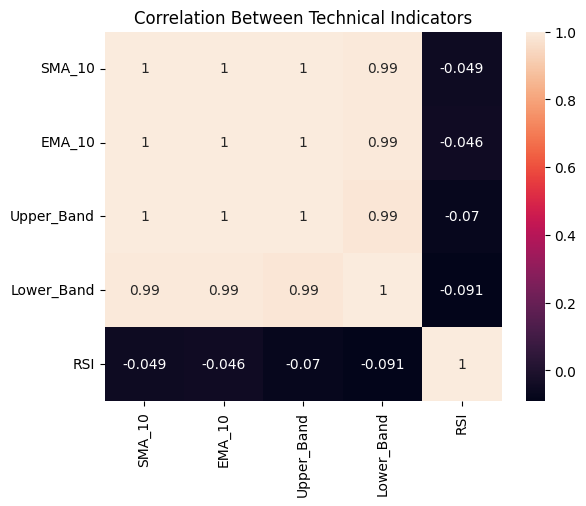

In [33]:
# Identify correlation between technical indicators
correlation_matrix = bitcoin_data[['SMA_10','EMA_10','Upper_Band','Lower_Band','RSI']].corr()

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation Between Technical Indicators")
plt.show()

Explanation:- This code calculates and visualizes the correlation between different technical indicators to understand how they are related to each other.

#4. Model Training and Selection:
• Train different machine learning models:

In [34]:
from sklearn.linear_model import LinearRegression

# Create Linear Regression model
model = LinearRegression()

# Train the model using training data
model.fit(X_train, y_train)

LinearRegression()

Random Forest

In [35]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

Support Vector Machine (SVM)

In [36]:
from sklearn.svm import SVR

# Create SVM model
svm_model = SVR(kernel='rbf')

# Train the model
svm_model.fit(X_train, y_train)

SVR()

XGBoost (Extreme Gradient Boosting)

In [37]:
from xgboost import XGBRegressor

# Create XGBoost model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

LSTM (Long Short-Term Memory) for deep learning

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Create LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=False, input_shape=(X_train.shape[1], 1)))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 36577060.0000
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 36517856.0000
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 36473028.0000
Epoch 4/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 36426188.0000
Epoch 5/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 36381316.0000
Epoch 6/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 36341948.0000
Epoch 7/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 36306820.0000
Epoch 8/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 36272172.0000
Epoch 9/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 36238700.0000
Epoch 10/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 36206452.0000


Compare model performance using RMSE (Root Mean Squared Error).

In [39]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Linear Regression prediction
lr_pred = model.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

# Random Forest prediction
rf_pred = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

# SVM prediction
svm_pred = svm_model.predict(X_test)
svm_rmse = np.sqrt(mean_squared_error(y_test, svm_pred))

# XGBoost prediction
xgb_pred = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("Linear Regression RMSE:", lr_rmse)
print("Random Forest RMSE:", rf_rmse)
print("SVM RMSE:", svm_rmse)
print("XGBoost RMSE:", xgb_rmse)

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Linear Regression RMSE: 42612.71769186589
Random Forest RMSE: 27989.562000359358
SVM RMSE: 39093.58844514597
XGBoost RMSE: 28648.38085116931


#5. Model Evaluation and Prediction:
Evaluate the best model based on:

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions using XGBoost model (example)
y_pred = xgb_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 24578.193918009583
Mean Squared Error (MSE): 820729725.3936443
R2 Score: -2.347042240890297


Explanation:- This code evaluates the model using MAE, MSE, and R² Score to measure prediction error and overall model accuracy.

Predict Bitcoin price trends using real-time data from APIs (e.g., Binance,
CoinGecko).

In [41]:
import requests

# Get real-time Bitcoin price
url = "https://api.coingecko.com/api/v3/simple/price?ids=bitcoin&vs_currencies=usd"

response = requests.get(url)
data = response.json()

print("Current Bitcoin Price (USD):", data['bitcoin']['usd'])

Current Bitcoin Price (USD): 72049


#Conclusion

This project uses machine learning techniques to analyze historical Bitcoin data and predict price trends. By using different models such as Linear Regression, Random Forest, SVM, and XGBoost, the system can learn patterns from past data and help estimate future Bitcoin prices. In the future, advanced deep learning models like LSTM or Transformer networks can be used to improve prediction accuracy and capture more complex market patterns.